# SEM Elastic Wave Simulation for QC
Modification of Schade et al. 2023 


## Importing Dependencies

In [35]:
from simulation.experiment import ForwardExperiment1D
from utility.distributions import (spike, ricker, gaussian, raised_cosine,
                                    sinc, homogeneous, exponential, polynomial)


## Defining Simulation Parameters

In [112]:
# Set Experiment Parameters
import numpy as np                                 
nx = 61
order = 5
parameters = {
    'L': 10,                                        # Domain len
    'nx': nx,                                       # Number of grid points
    'dt': 0.0001,                                   # Time stepping
    'nt': 200,                                       # Number of time steps
    'order': order,                                     # Finite-difference order
    'mu': homogeneous(3e10, nx),   # Elastic modulus distribution
    'rho': homogeneous(2e3, nx),    # Density distribution
    # 'mu': raised_cosine(3e10, nx+1, nx, nx, 1e10),   # Elastic modulus distribution
    # 'rho': raised_cosine(2e3, nx, nx-1, nx, 2e3), 
    'u': gaussian(1, nx, nx//2, nx//10),                           # Initial positions
    # 'u': spike(1, nx, nx//2),                           # Initial positions
    'v': homogeneous(0, nx),                        # Initial velocities
    'backend': {
        'synthesis': 'MatrixExponential',           # Time Evolution Synthesis Method
        'batch_size': 100,                          # Circuit Batch Size
        'backend': 'ibm_fez',            # Cloud backend name
        'shots': 500,                              # Number of circuit samples
        'optimization': 3,                          # Circuit optimization level
        'resilience': 1,                            # Circuit resilience level
        'seed': 0,                                  # Transpilation seed
        'local_transpilation': False,               # Local transpilation
        'method': 'matrix_product_state',                    # Classical simulation method
        'fake': None,                               # Fake backend model (Currently not supported)
        }
    }

## Running Simulation Experiment

2026-06-29 15:54:57,091 - INFO - Created experiment with time stamp: 20260629T155457.

2026-06-29 15:54:57,092 - INFO - Adding solver 1: exp
2026-06-29 15:54:57,094 - INFO - Parameters checked for validity.
2026-06-29 15:54:57,095 - INFO - Solving for 200 time steps.
2026-06-29 15:54:57,100 - INFO - Calculating Transformation and Hamiltonian.


Assembling global matrices...
shapes of matrix: 1) M: (59, 59) 2) K (59, 59) 3) U_global: (59, 59)
2.9103830456733704e-11
B.T @ B - K_hat: 2.384185791015625e-07
U_global.T @ U_global - K_hat: 2.86102294921875e-06
H shape: (118, 118) T shape: (118, 118)
H matrix max eigenvalue: 78635.61702362458
✓ Hermitian: max|H - H†| = 0.000e+00


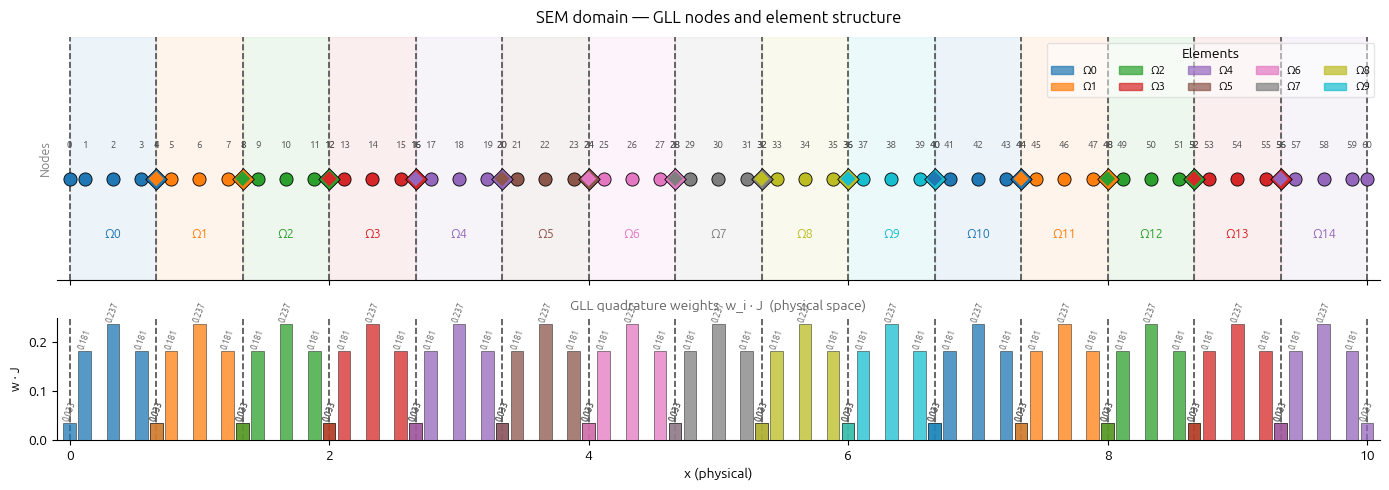

2026-06-29 15:54:58,954 - INFO - Calculation completed.
2026-06-29 15:54:58,955 - INFO - Medium initialized.
2026-06-29 15:54:58,957 - INFO - Initial state forward-transformed.
2026-06-29 15:54:58,957 - INFO - Solver 0 added.



tf.nx: 59
u shape: 59
transform: (118, 118)
118 118


In [113]:
# Create new Experiment
experiment = ForwardExperiment1D(verbose=2)
#experiment.add_solver('ode', **parameters)
experiment.add_solver('exp', **parameters)
# experiment.add_solver('local', **parameters)
# experiment.add_solver('cloud', **parameters)


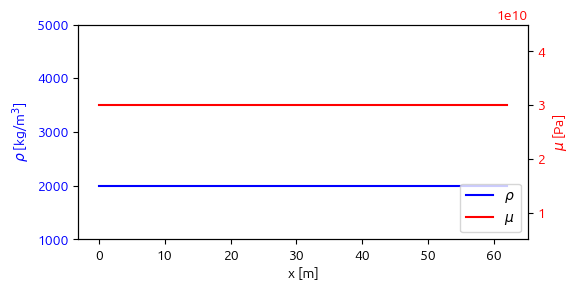

In [114]:
# Plot medium properties
experiment.plot('medium', solvers=[0])
# # Plot initial conditions
# experiment.plot('initial', solvers=[0])


## RUN THE EXPERIMENT

In [115]:
results = experiment.run()

2026-06-29 15:55:05,241 - INFO - Running solver 1: exp
2026-06-29 15:55:05,243 - INFO - Solving matrix exponential.
2026-06-29 15:55:07,078 - INFO - Matrix exponential solved.
2026-06-29 15:55:07,280 - INFO - States inverse-transformed.
2026-06-29 15:55:07,281 - INFO - Saving data.
2026-06-29 15:55:07,283 - INFO - Solver 1 completed in 0:00:02.039345.



In [40]:
# Plot one of the quantum circuits
experiment.plot('circuit', solvers=[0], group=0, idx=0)


AttributeError: 'Solver1DEXP' object has no attribute 'circuit_groups'

## Loading Simulation Experiment

In [88]:
from simulation.experiment import ForwardExperiment1D

In [42]:
# Load experiment from the cloud / local with experiment ID
exp_id = '20260426T202938'
experiment = ForwardExperiment1D(experiment_id=exp_id, verbose=2, data_folder='data')
results = experiment.load()


FileNotFoundError: No experiment with time stamp 20260426T202938 found.

In [116]:
field = results[0].pop('field')
print(field.keys())
u_exp = field['u']
state = field['state']

dict_keys(['u', 'v', 'state'])


In [117]:
## Save the statevector
np.save('u_exp.npy', u_exp)

In [118]:
##Load the statevector
u_exp = np.load('u_exp.npy')
u_fd = np.load('u_fd(true)4th.npy')

## Visualizing Results

In [119]:
## interpolate statevector to 1000 gridpoints
def interpolate_u(u_exp, L):
    from scipy.interpolate import interp1d
    import numpy as np

    # Ensure x matches the spatial dimension of u_ref
    x = np.linspace(0, L, u_exp.shape[1])

    # Fine grid
    x_fine = np.linspace(0, L, 1000)

    # Interpolate u_exp onto fine grid for each time step
    u_exp_interp = np.zeros((u_exp.shape[0], 1000))
    for i in range(u_exp.shape[0]):
        interp_func = interp1d(x, u_exp[i], kind='linear')
        u_exp_interp[i] = interp_func(x_fine)

    # Now u_exp_interp is interpolated on x_fine
    return u_exp_interp

In [120]:
L = 10
u_exp_interp = interpolate_u(u_exp,L)
u_fd_interp = interpolate_u(u_fd,L)
x_fine = np.linspace(0, L, 1000)
print(u_exp_interp.shape)
print(u_fd_interp.shape)

(200, 1000)
(20, 1000)


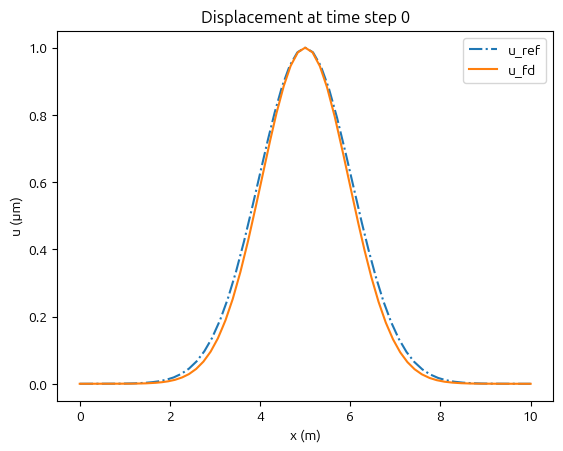

In [121]:
#plot initial SEM vs FDM
import numpy as np
import matplotlib.pyplot as plt

t = 0 # Choose time index (0 to nt-1)
#plt.plot(x_fine, u_ref_interp[t], label='u_sem', linestyle='--')
plt.plot(x_fine, u_exp_interp[t], label='u_ref',linestyle='-.')
plt.plot(x_fine, u_fd_interp[t], label='u_fd', linestyle='-')
plt.xlabel('x (m)')
plt.ylabel('u (μm)')
plt.title(f'Displacement at time step {t}')
plt.legend()
plt.savefig('initial.png',dpi=300)
plt.show()


In [164]:
# Define the dt for each array (could be different if from different sources)
dt_sem = 0.0001 # or specify individually if different
dt_exp = 0.0001# or specify individually if different
dt_fd = 0.0001  # or specify individually if different
T = [0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005]

u_exp: dt=0.0001, nt=200, max_time=0.02000s
u_fd:  dt=0.0001, nt=20, max_time=0.00200s


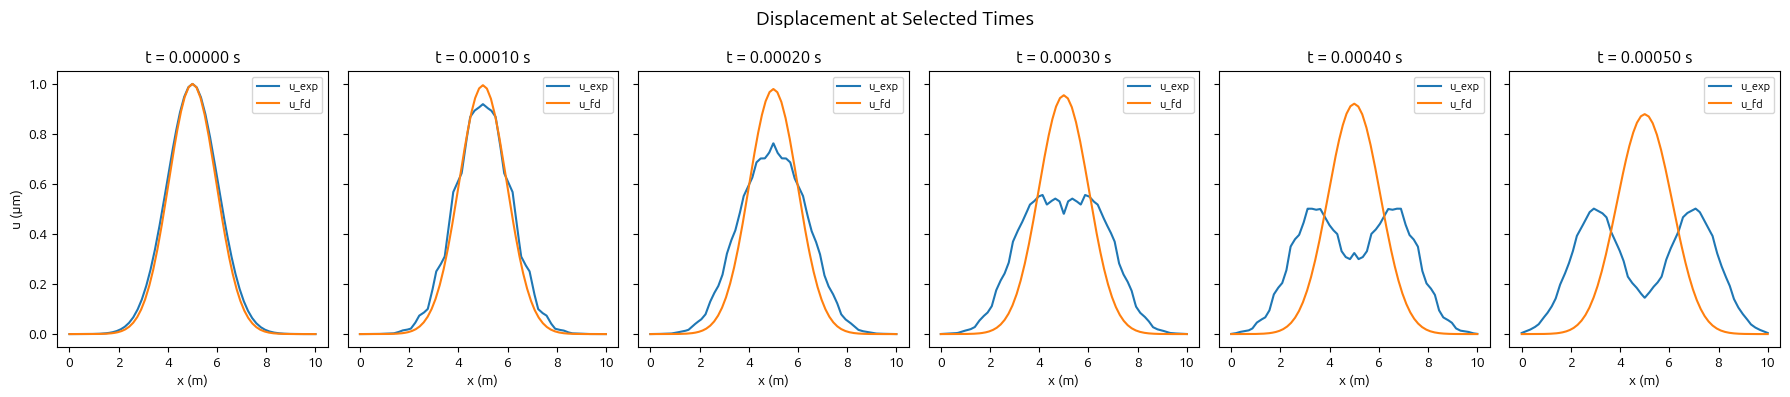

In [165]:
#plot FDM vs SEM snapshots and save u at time T
import numpy as np
import matplotlib.pyplot as plt

# nt_sem = u_sem_interp.shape[0]
nt_exp = u_exp_interp.shape[0]
nt_fd = u_fd_interp.shape[0]
u_expT = []
u_fdT = []

# print(f"u_sem: dt={dt_sem}, nt={nt_sem}, max_time={nt_sem*dt_sem:.5f}s")
print(f"u_exp: dt={dt_exp}, nt={nt_exp}, max_time={nt_exp*dt_exp:.5f}s")
print(f"u_fd:  dt={dt_fd}, nt={nt_fd}, max_time={nt_fd*dt_fd:.5f}s")

# Choose 5 specific times (in seconds) to display
times_in_seconds = np.array([0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005])

fig, axes = plt.subplots(1, len(times_in_seconds), figsize=(18, 4), sharey=True)

for ax, t_sec in zip(axes, times_in_seconds):
    # Calculate the time step index for each array at this specific time
    # idx_sem = int(np.round(t_sec / dt_sem))
    idx_exp = int(np.round(t_sec / dt_exp))
    idx_fd = int(np.round(t_sec / dt_fd))

    # Clip to valid range
    # idx_sem = np.clip(idx_sem, 0, nt_sem - 1)
    idx_exp = np.clip(idx_exp, 0, nt_exp - 1)
    idx_fd = np.clip(idx_fd, 0, nt_fd - 1)
    
    # Plot using the calculated indices
    # ax.plot(x_fine, u_sem_interp[idx_sem], label='u_sem', linestyle='--')
    ax.plot(x_fine, u_exp_interp[idx_exp], label='u_exp', linestyle='-')
    ax.plot(x_fine, u_fd_interp[idx_fd], label='u_fd', linestyle='-')
    u_expT.append(u_exp_interp[idx_exp])
    u_fdT.append(u_fd_interp[idx_fd])
    # ax.plot(x_fine, u_fdexp_interp[idx_fd], label='u_fd', linestyle='-')
    ax.set_xlabel('x (m)')
    ax.set_title(f't = {t_sec:.5f} s')
    ax.legend(fontsize=8)


axes[0].set_ylabel('u (μm)')
fig.suptitle('Displacement at Selected Times', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Analytical Solution


In [166]:
import numpy as np

def u_dalembert(x, t, mu, rho, x0, sigma):
    """
    Analytical 1D wave solution: Gaussian initial displacement, zero initial velocity.
    Valid on an unbounded domain, or on [0, L] before the pulse reaches a boundary
    (i.e. while  x0 - c*t > 0  and  x0 + c*t < L).

    Parameters
    ----------
    x     : array of evaluation points (your FDM/SEM grid)
    t     : evaluation time (e.g. T_final)
    mu    : shear modulus
    rho   : density
    x0    : pulse center
    sigma : Gaussian width
    """
    c = np.sqrt(mu / rho)
    def f(xi):
        return np.exp(-(xi - x0)**2 / (2.0 * sigma**2))
    return 0.5 * (f(x - c*t) + f(x + c*t))


In [187]:
x_sem = np.load('x_sem.npy')
from scipy.interpolate import interp1d
u_ref =[]

x_fine = np.linspace(0, 10, 1000)

 # Interpolate u_sem onto fine grid for each time step
u_ref_interp = np.zeros((1000,))
for i, t in enumerate(T):
    results = u_dalembert(x_sem, t, 3e10, 2e3, 10//2, 10//10)
    x = np.linspace(0, 10, results.shape[0])
    interp_func = interp1d(x, results, kind='linear')
    u_ref_interp = interp_func(x_fine)
    u_ref.append(u_ref_interp)
print(len(u_expT), len(u_fdT), len(u_ref))

6 6 6


--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [158]:
#test norm conservation
print("max of sem:", np.max(u_exp_interp))
print("max of anal:", np.max(u_ref_interp))
print("max of fd:", np.max(u_fd_interp))

max of sem: 0.999599605991568
max of anal: 0.49912454742539425
max of fd: 0.9995719926114885


## Final Plot

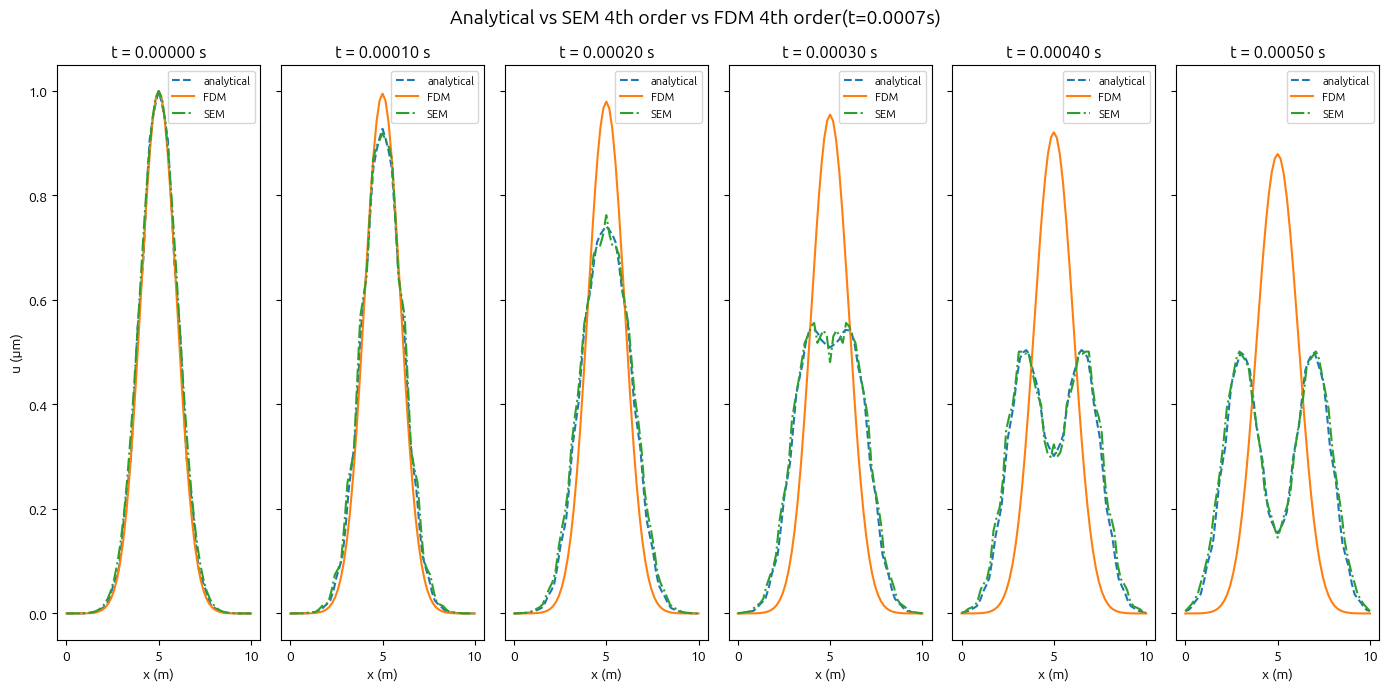

In [ ]:

filename = 'Sem2nd vs FDM4th(nx= 61)'
compared = 'Analytical vs SEM 4th order vs FDM 4th order'
fig, axes = plt.subplots(1, len(T), figsize=(14, 7), sharey=True)

for nn, t_sec in enumerate(T):
    axes[nn].plot(x_fine, u_ref[nn], label='analytical', linestyle='--')
    axes[nn].plot(x_fine, u_fdT[nn], label='FDM', linestyle='-')
    axes[nn].plot(x_fine, u_expT[nn], label='SEM', linestyle='-.')
    axes[nn].set_xlabel('x (m)')
    axes[nn].set_title(f't = {t_sec:.5f} s')
    axes[nn].legend(fontsize=8)


axes[0].set_ylabel('u (μm)')
fig.suptitle(compared, fontsize=14, fontweight='bold')
plt.savefig(filename)
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1000,) and (6, 1000)

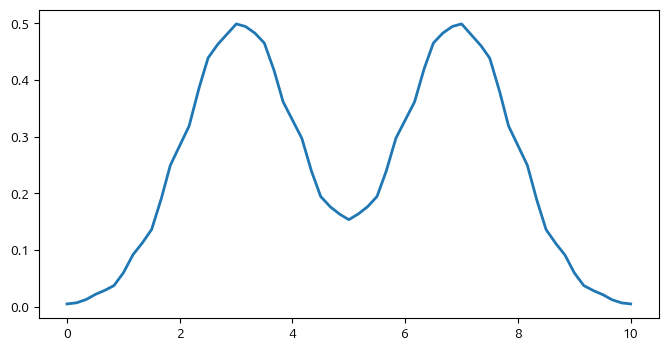

In [186]:
filename = 'Sem2nd vs FDM4th(nx= 61)'
compared = 'Analytical vs SEM 4th order vs FDM 4th order(t=0.0007s)'
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(x_fine, u_ref_interp, label='Analytical', color='C0', linewidth=2)
plt.plot(x_fine, u_expT, label='SEM', color='C1', linestyle='--', linewidth=2)
plt.plot(x_fine, u_fdT, label='FD', color='C2', linestyle='-.', linewidth=2)

plt.xlabel('x')
plt.ylabel('u')
plt.title(compared)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(filename)
plt.show()


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## DISPERSION ANALYSIS


In [101]:
M_sem =np.load('M_sem.npy')
K_sem = np.load('K_sem.npy')
M_fd = np.load('M_fd.npy')
K_fd = np.load('K_fd.npy')
Ktilde = np.load('Ktilde.npy')
print(M_sem.shape, K_sem.shape, M_fd.shape, K_fd.shape)

(59, 59) (59, 59) (62, 62) (31, 31)


In [102]:
inv_sqrt_M = np.diag(1.0 / np.sqrt(np.diag(M_sem)))
K_tilde    = inv_sqrt_M @ (-K_sem) @ inv_sqrt_M

omega_num  = np.sqrt(np.linalg.eigvalsh(K_tilde))
omega_num  = np.sort(omega_num)

# analytical eigenfrequencies for fixed-fixed string: omega_n = n*pi*c/L
c = np.sqrt(3e10 / 2e3)
n = np.arange(1, 6)
omega_ana = n * np.pi * c / 10

print("Numerical  :", omega_num[:5])
print("Analytical :", omega_ana)
print("Ratio      :", omega_num[:5] / omega_ana)   # should be ~1.0


Numerical  : [1216.73355197 2433.46557765 3650.18842587 4866.8821096  6083.50791685]
Analytical : [1216.73360279 2433.46720558 3650.20080838 4866.93441117 6083.66801396]
Ratio      : [0.99999996 0.99999933 0.99999661 0.99998925 0.99997368]


In [103]:
c_phys = np.sqrt(3e10 / 2e3)
print(f"Physical wave speed: {c_phys:.2f} m/s"  )

Physical wave speed: 3872.98 m/s


No zero mode (BCs applied) — starting at index 0
Modes kept after filtering: 15 / 15


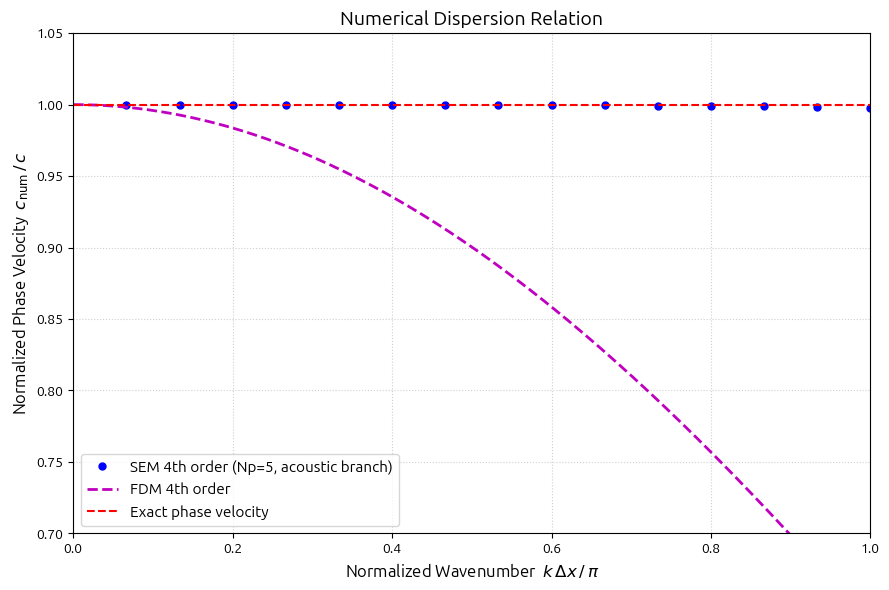

Total DOFs        : 59
Total modes       : 59
Zero mode omega   : 1.2167e+03  (should be ~0)
Acoustic modes    : 15
k_norm range      : [0.067, 1.000]
c_norm range      : [1.000000, 0.997686]


In [111]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh

def plot_my_dispersion(M_sem, K_sem, c_phys, L, dx_el, Np, Nel):
    """
    Parameters
    ----------
    M_sem  : global mass matrix      (N_dof x N_dof)
    K_sem  : global stiffness matrix (N_dof x N_dof)  -- should be negative semi-definite
    c_phys : physical wave speed
    L      : domain length
    dx_el  : element size  (= L / Nel)
    Np     : nodes per element  (e.g. 4)
    Nel    : number of elements
    """

    # ------------------------------------------------------------------
    # 1. Solve GENERALIZED eigenvalue problem  K v = omega^2 M v
    #    eigh handles symmetric matrices stably — no need for inv(M)
    #    K is negative semi-definite, so negate it: -K v = omega^2 M v
    # ------------------------------------------------------------------
    vals, _ = eigh(-K_sem, M_sem)          # vals are omega^2, ascending
    vals    = np.abs(vals)                 # remove tiny negative rounding noise
    omega_all = np.sqrt(vals)              # all frequencies, sorted ascending

    # ------------------------------------------------------------------
    # 2. Extract ACOUSTIC branch only
    #    For Np-order SEM with Nel elements:
    #      - Total DOFs          : Nel*(Np-1) + 1
    #      - Acoustic modes      : Nel   (one per element, lowest frequencies)
    #      - Optical/spurious    : the rest
    #    After removing the zero (rigid body) mode at index 0, acoustic
    #    modes are indices 1 .. Nel
    # ------------------------------------------------------------------
#     omega_acoustic = omega_all[0 : Nel]         # skip zero mode, take Nel modes

# Check: if zero mode truly exists, omega_all[0] ~ 0
# If BCs applied, omega_all[0] is already the first physical mode
    zero_mode_threshold = 1e-3 * omega_all[-1]   # 0.1% of max frequency

    if omega_all[0] < zero_mode_threshold:
        print("Zero mode detected — skipping index 0")
        omega_acoustic = omega_all[1 : Nel + 1]   # skip rigid body
    else:
        print("No zero mode (BCs applied) — starting at index 0")
        omega_acoustic = omega_all[0 : Nel]        # no skip

    # Corresponding exact wavenumbers
    n_modes  = np.arange(1, Nel + 1)
    k_exact  = n_modes * np.pi / L                  # k_n = n*pi/L

    # Normalized wavenumber for x-axis
    k_norm_sem = (k_exact * dx_el) / np.pi          # in [0, 1]

    # Numerical phase velocity
    c_num_sem  = omega_acoustic / k_exact
    c_norm_sem = c_num_sem / c_phys

    # ------------------------------------------------------------------
    # 3. Theoretical FD 2nd order phase velocity
    #    c_num_FD = c * sin(k*dx/2) / (k*dx/2)
    #    Use dx = dx_el for a fair same-mesh comparison
    # ------------------------------------------------------------------
    mask           = c_norm_sem <= 1.0         # 2% tolerance for rounding
    omega_acoustic = omega_acoustic[mask]
    k_plot         = k_exact[mask]
    c_norm_sem     = c_norm_sem[mask]
    k_norm_sem     = (k_plot * dx_el) / np.pi

    print(f"Modes kept after filtering: {mask.sum()} / {Nel}")

    k_th      = np.linspace(1e-3, np.pi / dx_el, 300)
    arg       = k_th * dx_el / 2.0
    c_fd      = c_phys * np.sin(arg) / arg
    k_norm_fd = (k_th * dx_el) / np.pi

    # ------------------------------------------------------------------
    # 4. Theoretical SEM 2nd order (Np=2) phase velocity
    #    Same formula as FD for Np=2 on same mesh
    #    (GLL with 2 nodes = standard linear FE = same dispersion as FD2)
    # ------------------------------------------------------------------
    c_sem2 = c_phys * np.sin(arg) / arg   # identical to FD2 for Np=2

    # ------------------------------------------------------------------
    # 5. Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(k_norm_sem, c_norm_sem,
            'bo', markersize=5, label=f'SEM {Np-1}th order (Np={Np}, acoustic branch)')

    # ax.plot(k_norm_fd, c_fd / c_phys,
            # 'g-', linewidth=2, label='FD 2nd order (theoretical)')

    ax.plot(k_norm_fd, c_sem2 / c_phys,
            'm--', linewidth=2, label='FDM 4th order ')

    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5,
               label='Exact phase velocity')

    ax.set_xlabel(r'Normalized Wavenumber  $k\,\Delta x\,/\,\pi$', fontsize=12)
    ax.set_ylabel(r'Normalized Phase Velocity  $c_\mathrm{num}\,/\,c$', fontsize=12)
    ax.set_title('Numerical Dispersion Relation', fontsize=14)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0.7, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig('Dispersion Plot SEM4th(nx = 61)')
    plt.show()

    # ------------------------------------------------------------------
    # 6. Diagnostic print — helps verify branch extraction is correct
    # ------------------------------------------------------------------
    print(f"Total DOFs        : {M_sem.shape[0]}")
    print(f"Total modes       : {len(omega_all)}")
    print(f"Zero mode omega   : {omega_all[0]:.4e}  (should be ~0)")
    print(f"Acoustic modes    : {len(omega_acoustic)}")
    print(f"k_norm range      : [{k_norm_sem[0]:.3f}, {k_norm_sem[-1]:.3f}]")
    print(f"c_norm range      : [{c_norm_sem[0]:.6f}, {c_norm_sem[-1]:.6f}]")

Np  = 5
Nel = int((nx - 1) / (Np - 1))
dx_el = 10 / Nel

plot_my_dispersion(M_sem, K_sem, c_phys, L=10.0, dx_el=dx_el, Np=Np, Nel=Nel)


In [23]:
print(M_sem.shape, K_sem.shape)

(59, 59) (59, 59)


In [105]:
peak_sem = np.max(np.abs(u_exp_interp))
peak_fd = np.max(np.abs(u_fd_interp))
peak_ref = np.max(np.abs(u_exp_interp))

print(f"SEM Peak Retention: {peak_sem/peak_ref * 100}%")
print(f"FD Peak Retention: {peak_fd/peak_ref * 100}%")


SEM Peak Retention: 100.0%
FD Peak Retention: 98.94285305526196%


In [106]:
# Lowest exact frequency for Dirichlet BCs
omega_exact_1 = np.pi * c_phys / 10

# Lowest numerical frequency from your matrices
eigvals = eigh(-K_sem, M_sem, eigvals_only=True)
omega_num_1 = np.sqrt(np.maximum(eigvals[0], 0.0))

print("omega_exact_1:", omega_exact_1)
print("omega_num_1:  ", omega_num_1)
print("ratio:        ", omega_num_1 / omega_exact_1)  # should be 1.0000

omega_exact_1: 1216.7336027920835
omega_num_1:   1216.7335519688886
ratio:         0.999999958229809


In [107]:
print("c_phys used in omega_exact:", c_phys)
print("sqrt(mu/rho):", np.sqrt(3e10/2e3))
print("L:", 10)
print("Nel:", Nel)
print("Np:", Np)  
print("(nx-1)/(Np-1):", (nx-1)/(Np-1))  # should be integer
print("Nel * (Np-1) + 1:", Nel*(Np-1)+1)  # should equal nx

c_phys used in omega_exact: 3872.983346207417
sqrt(mu/rho): 3872.983346207417
L: 10
Nel: 30
Np: 3
(nx-1)/(Np-1): 30.0
Nel * (Np-1) + 1: 61


## L2 ERROR


In [110]:
import numpy as np

def calculate_l2_error(u_test, u_ref):
    """
    Calculates the relative L2 error between a test wave and a reference wave.
    Both arrays must have the same shape.
    """
    # 1. Calculate the absolute difference squared
    diff_sq = (u_test - u_ref)**2
    
    # 2. Calculate the reference magnitude squared (for normalization)
    ref_sq = u_ref**2
    
    # 3. Compute the relative L2 error
    # We use the square root of the ratio of sums
    l2_error = np.sqrt(np.sum(diff_sq)) / np.sqrt(np.sum(ref_sq))
    
    return l2_error


error_sem = calculate_l2_error(u_exp_interp, u_ref_interp)
error_fd  = calculate_l2_error(u_fd_interp, u_ref_interp)

print(f"Relative L2 Error (SEM): {error_sem:.4f}")
print(f"Relative L2 Error (FD):  {error_fd:.4f}")


Relative L2 Error (SEM): 20.2218
Relative L2 Error (FD):  5.2984


In [108]:
phi0 = np.load('phi0.npy')
H = np.load('H_sem.npy')
print("phi0 shape:", phi0.shape)
print("H shape:", H.shape)
phi0fd = np.load('phi0_fd.npy')
H_fd = np.load('H_fd.npy')
print("phi0fd shape:", phi0fd.shape)
print("H_fd shape:", H_fd.shape)

phi0 shape: (118,)
H shape: (118, 118)
phi0fd shape: (64,)
H_fd shape: (64, 64)


## Energy plot

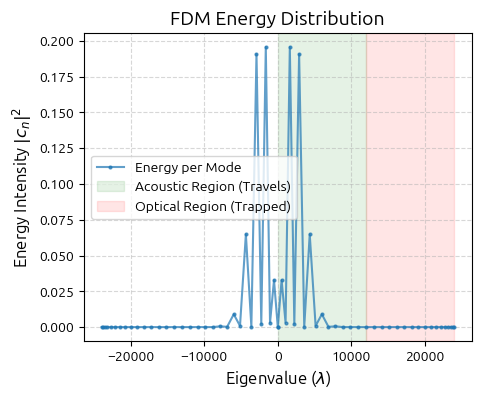

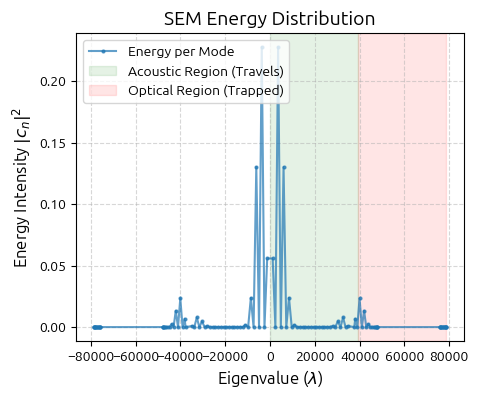

In [109]:
import numpy as np
import matplotlib.pyplot as plt

def plot_energy_distribution(H, psi_0, title="Energy Distribution"):
    """
    H: The Hamiltonian matrix (SEM or FD)
    psi_0: The initial Gaussian state vector
    """
    
    # 1. Compute Eigenvalues (w) and Eigenvectors (v)
    # Use eigh because H is symmetric
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    
    # 2. Project psi_0 onto the Eigenbasis
    # c_n = <phi_n | psi_0>
    coeffs = np.dot(eigenvectors.T, psi_0)
    
    # 3. Calculate Energy (Probability) in each mode
    # Energy_n = |c_n|^2
    energy_dist = np.abs(coeffs)**2
    
    # 4. Plotting
    plt.figure(figsize=(5, 4))
    
    # We plot against the eigenvalue magnitude
    plt.plot(eigenvalues, energy_dist, 'o-', markersize=2, alpha=0.7, label='Energy per Mode')
    
    # Highlight the "Physical" vs "Spurious" regions
    max_eig = np.max(eigenvalues)
    plt.axvspan(0, max_eig/2, color='green', alpha=0.1, label='Acoustic Region (Travels)')
    plt.axvspan(max_eig/2, max_eig, color='red', alpha=0.1, label='Optical Region (Trapped)')
    
    plt.title(title, fontsize=14)
    plt.xlabel('Eigenvalue ($\lambda$)', fontsize=12)
    plt.ylabel('Energy Intensity $|c_n|^2$', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Usage:
plot_energy_distribution(H_fd, phi0fd, "FDM Energy Distribution")
plot_energy_distribution(H, phi0, "SEM Energy Distribution")
